<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day4/TS_forecasting_passengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q neuralforecast utilsforecast
!pip show neuralforecast

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataset

import pytorch_lightning as pl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.7/257.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

### Toy dataset (Air passengers, seasonality: 12)

In [2]:
from neuralforecast.utils import AirPassengers, AirPassengersPanel, AirPassengersStatic, augment_calendar_df
AirPassengersPanel, calendar_cols = augment_calendar_df(df=AirPassengersPanel, freq='M')

horizon = 12
Y_train_df = AirPassengersPanel[AirPassengersPanel.ds<AirPassengersPanel['ds'].values[-horizon]] # 132 train
Y_test_df = AirPassengersPanel[AirPassengersPanel.ds>=AirPassengersPanel['ds'].values[-horizon]].reset_index(drop=True) # 12 test

### Metal price prediction (gold, silver, platinum)

In [3]:
gold_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/gold.csv'
silver_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/silver.csv'
platinum_url = 'https://raw.githubusercontent.com/SLCFLAB/DL-Forecasting/main/DL/day1/data/platinum.csv'

gold = pd.read_csv(gold_url, index_col=0, parse_dates=['Date'])
silver = pd.read_csv(silver_url, index_col=0, parse_dates=['Date'])
platinum = pd.read_csv(platinum_url, index_col=0, parse_dates=['Date'])

In [4]:
def preprocess(df, name):
    #df = df.reset_index()  # Date → 열로
    df = df.rename(columns={'Date': 'ds', df.columns[1]: 'y'})  # 두 번째 열이 가격이라고 가정
    df['unique_id'] = name
    #df['trend'] = df['y'].expanding().mean()  # 예시 trend: 누적 평균
    #df['y_[lag12]'] = df['y'].shift(12)       # 12개월 전 값
    #df['month'] = df['ds'].dt.month
    return df[['unique_id', 'ds', 'y']]

def temporal_split(df, h=12):
    train_list = []
    test_list = []

    for uid, gdf in df.groupby('unique_id'):
        gdf_sorted = gdf.sort_values('ds').reset_index(drop=True)
        train = gdf_sorted.iloc[:-h]
        test = gdf_sorted.iloc[-h:]
        train_list.append(train)
        test_list.append(test)

    Y_train_df = pd.concat(train_list).reset_index(drop=True)
    Y_test_df = pd.concat(test_list).reset_index(drop=True)
    return Y_train_df, Y_test_df

In [5]:
# gold_df = preprocess(gold, 'gold')
# silver_df = preprocess(silver, 'silver')
# platinum_df = preprocess(platinum, 'platinum')

# combined_df = pd.concat([gold_df, silver_df, platinum_df], axis=0).sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

# horizon = 252
# Y_train_df, Y_test_df = temporal_split(combined_df, h=horizon)

### Training Forecasting Models

In [6]:
from neuralforecast.models import NBEATS, NHITS, PatchTST
#from neuralforecast.models import DLinear, Autoforemr, Informer, DeepAR, iTransformer

horizon = 12

models = [
    NBEATS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    NHITS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    #PatchTST(h=horizon, input_size=8*horizon, loss=MAE(), max_steps=300),
    PatchTST(h=horizon,
            input_size=2*horizon,
            patch_len=2*horizon,
            stride=2*horizon,
            revin=False,
            hidden_size=16,
            n_heads=4,
            scaler_type='robust',
            loss=MAE(),
            learning_rate=1e-3,
            max_steps=300,
            val_check_steps=50,
            early_stop_patience_steps=2)
]

nf = NeuralForecast(models=models, freq='M')
nf.fit(df=Y_train_df, val_size=horizon)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
900       Non-trainable params
2.4 M     Total params
9.789     Total estimated mo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [14]:
forecasts = nf.predict(futr_df=Y_test_df)

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

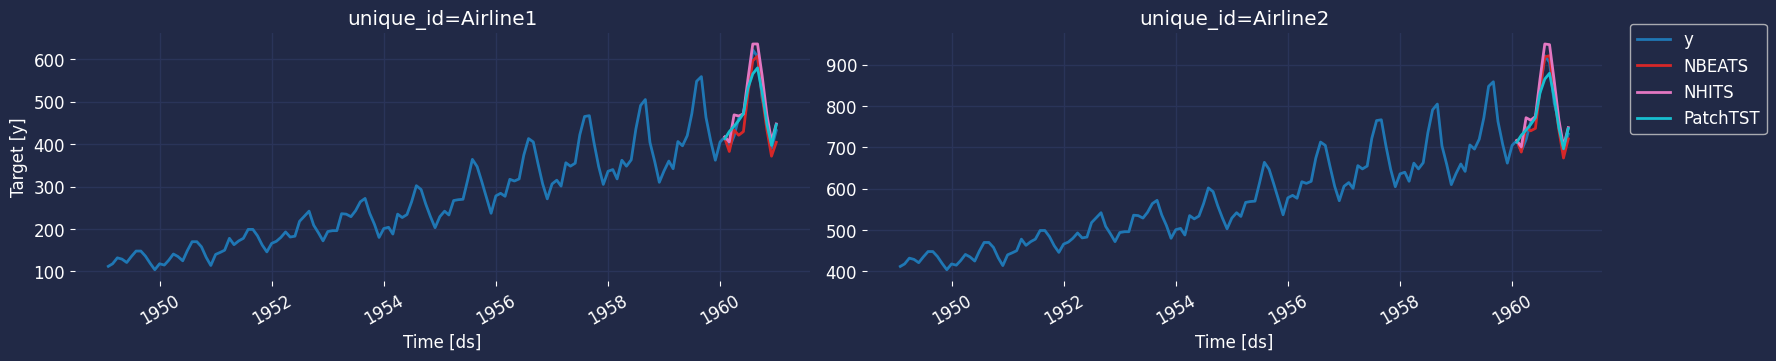

In [15]:
from utilsforecast.plotting import plot_series

plot_series(AirPassengersPanel, forecasts)

In [16]:
from sklearn.metrics import mean_absolute_error

mae_scores = {}

for uid in forecasts['unique_id'].unique():
    mae_scores[uid] = {}
    y_true = Y_test_df[Y_test_df['unique_id'] == uid]['y'].values

    for col in forecasts.columns:
        if col in ['ds', 'unique_id'] or col.endswith('lo-95') or col.endswith('hi-95'):
            continue

        y_pred = forecasts[forecasts['unique_id'] == uid][col].values
        y_pred = y_pred[:len(y_true)]  # 길이 맞추기 (예방적)
        mae = mean_absolute_error(y_true, y_pred)
        mae_scores[uid][col] = mae

print("MAE Scores (by series and model):")
for uid, model_dict in mae_scores.items():
    print(f"\n{uid}:")
    for model, score in model_dict.items():
        print(f"  {model}: {score:.3f}")

MAE Scores (by series and model):

Airline1:
  NBEATS: 18.978
  NHITS: 18.941
  PatchTST: 17.073

Airline2:
  NBEATS: 14.203
  NHITS: 21.770
  PatchTST: 17.073


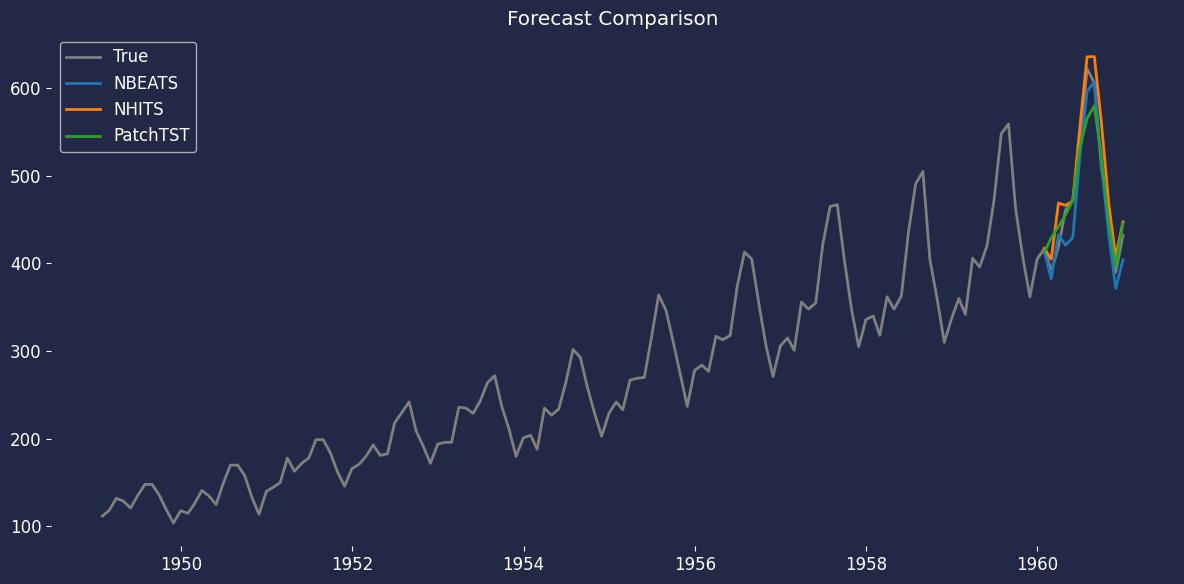

In [17]:

Y_hat_df = forecasts.reset_index(drop=True).drop(columns=['unique_id','ds'])
plot_df_nf = pd.concat([Y_test_df.reset_index(drop=True), Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df_nf])

plot_df = plot_df[plot_df['unique_id'] == 'Airline1']

plt.figure(figsize=(12, 6))
plt.plot(plot_df['ds'], plot_df['y'], label='True', c='grey')

for col in forecasts.columns:
    if 'median' in col or col.startswith('ds') or col.startswith('unique_id'):
        continue
    if 'PatchTST' in col and '-lo-' in col:
        continue  # Skip low/high intervals for now
    plt.plot(plot_df['ds'], plot_df[col], label=col)

plt.legend()
plt.title("Forecast Comparison")
plt.grid()
plt.tight_layout()
plt.show()

## StatsForecast

In [18]:
!pip install statsforecast

In [19]:
import matplotlib.pyplot as plt

dark_style = {
    'figure.facecolor': '#212946',
    'axes.facecolor': '#212946',
    'savefig.facecolor': '#212946',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'grid.color': '#2A3459',
    'grid.linewidth': 1,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'text.color': '#FFFFFF',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#FFFFFF',
    'ytick.color': '#FFFFFF',
    'font.size': 12,
    'lines.linewidth': 2
}
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,7)

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

## Time Series Analysis

In [22]:
df_p = AirPassengersPanel

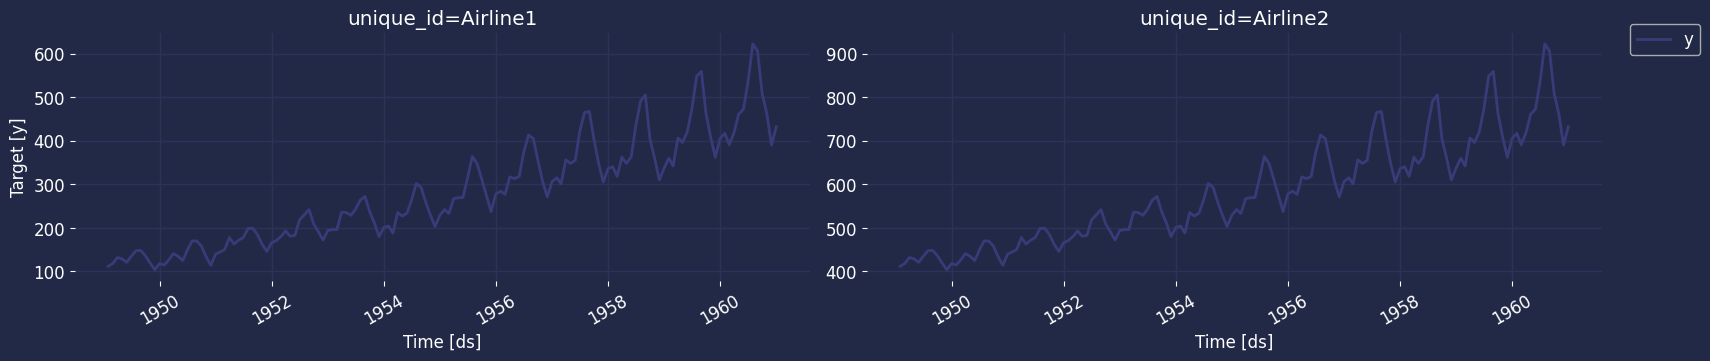

In [23]:
from statsforecast import StatsForecast

StatsForecast.plot(df_p)

,y
count,144.000000
mean,280.298615
std,119.966301
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


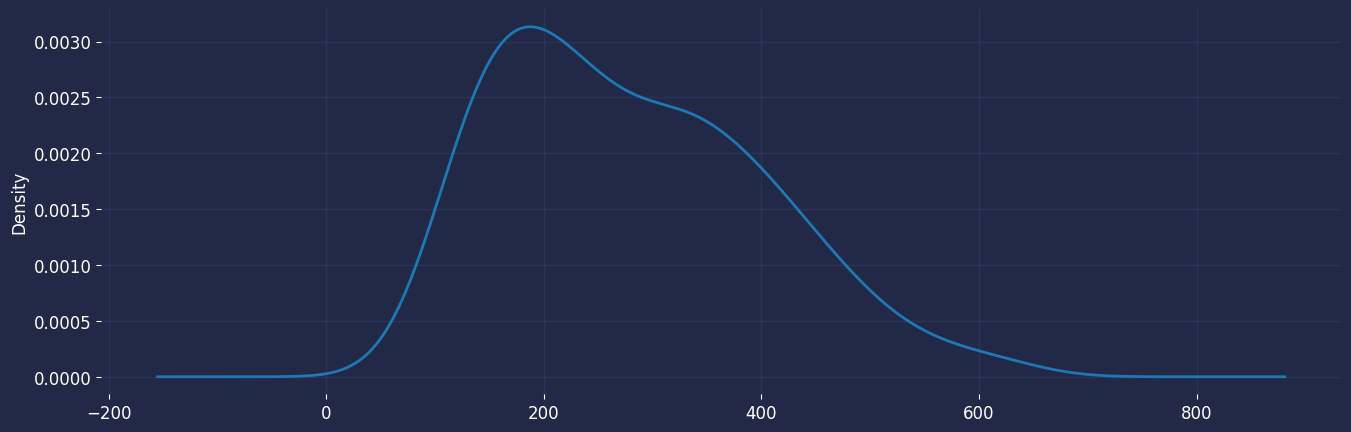

In [26]:
df = df_p[df_p['unique_id']=='Airline1']
df["y"].plot(kind='kde',figsize = (16,5))
df["y"].describe()

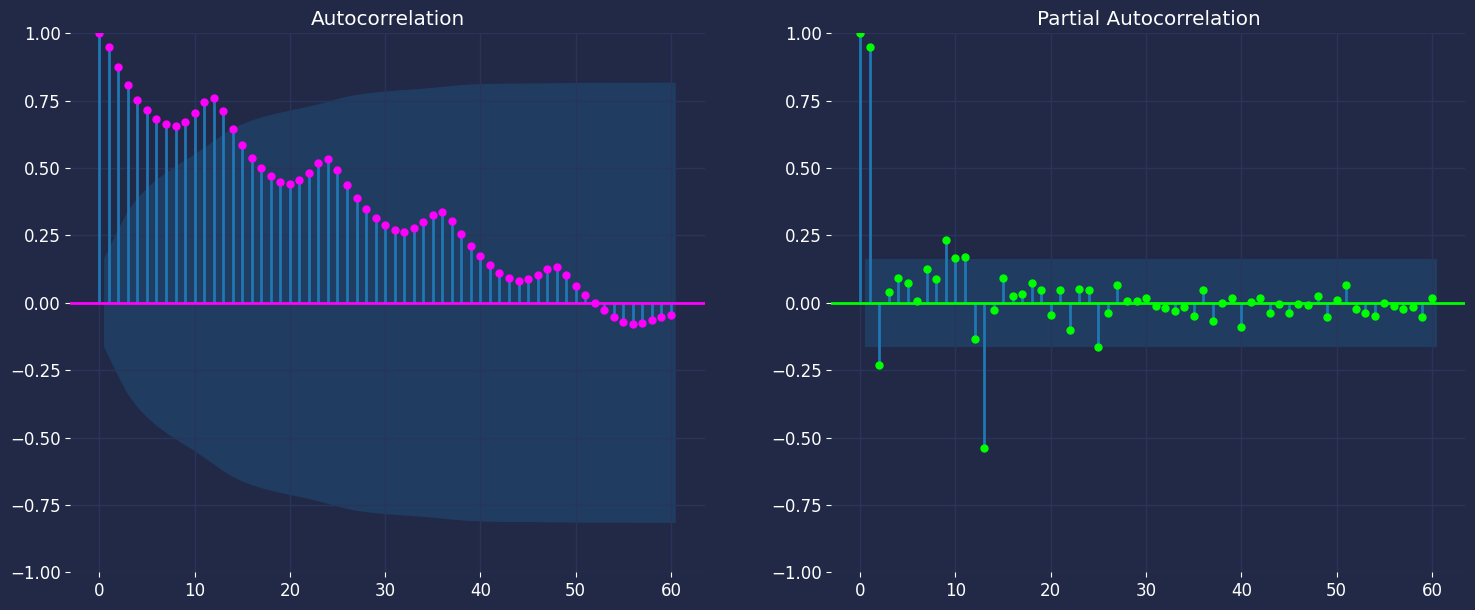

In [27]:
# Autocorrelation plot
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=60, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=60, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

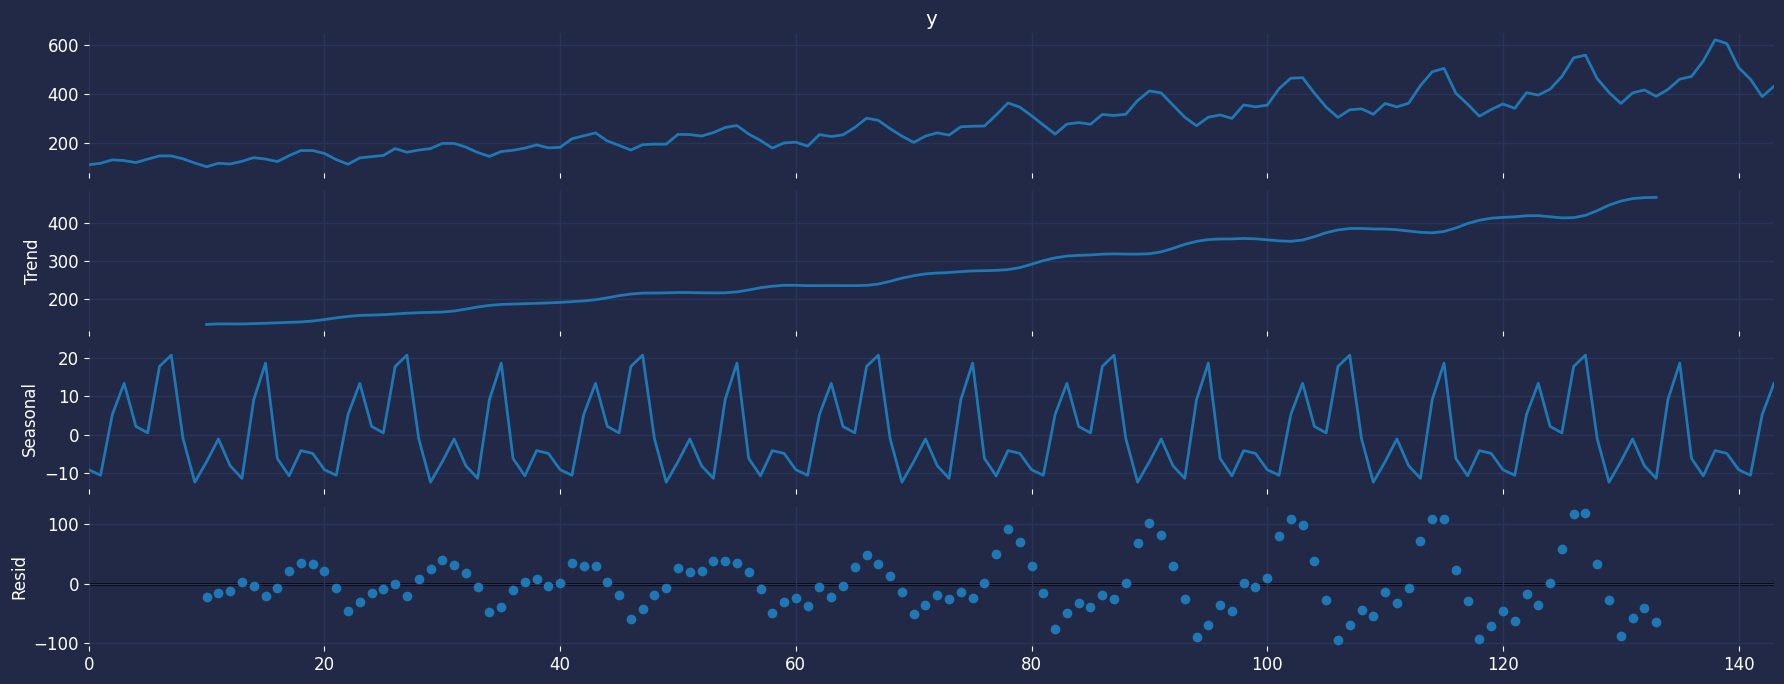

In [29]:
decomposed=seasonal_decompose(df["y"], model = "add", period=20)
decomposed.plot()
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller

In [31]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [32]:
Augmented_Dickey_Fuller_Test_func(df["y"],"metal")

Dickey-Fuller test results for columns: metal
Test Statistic                   0.815369
p-value                          0.991880
No Lags Used                    13.000000
Number of observations used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


In [33]:
df1=df.copy()
df1['y_diff'] = df['y'].diff()
df1.dropna(inplace=True)
df1.head()

,unique_id,ds,y,trend,y_[lag12],month,y_diff
1,Airline1,1949-02-28,118.0,1,118.0,-0.409091,6.0
2,Airline1,1949-03-31,132.0,2,132.0,-0.318182,14.0
3,Airline1,1949-04-30,129.0,3,129.0,-0.227273,-3.0
4,Airline1,1949-05-31,121.0,4,121.0,-0.136364,-8.0
5,Airline1,1949-06-30,135.0,5,135.0,-0.045455,14.0


In [34]:
Augmented_Dickey_Fuller_Test_func(df1["y_diff"],"metal_diff")

Dickey-Fuller test results for columns: metal_diff
Test Statistic                  -2.829267
p-value                          0.054213
No Lags Used                    12.000000
Number of observations used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


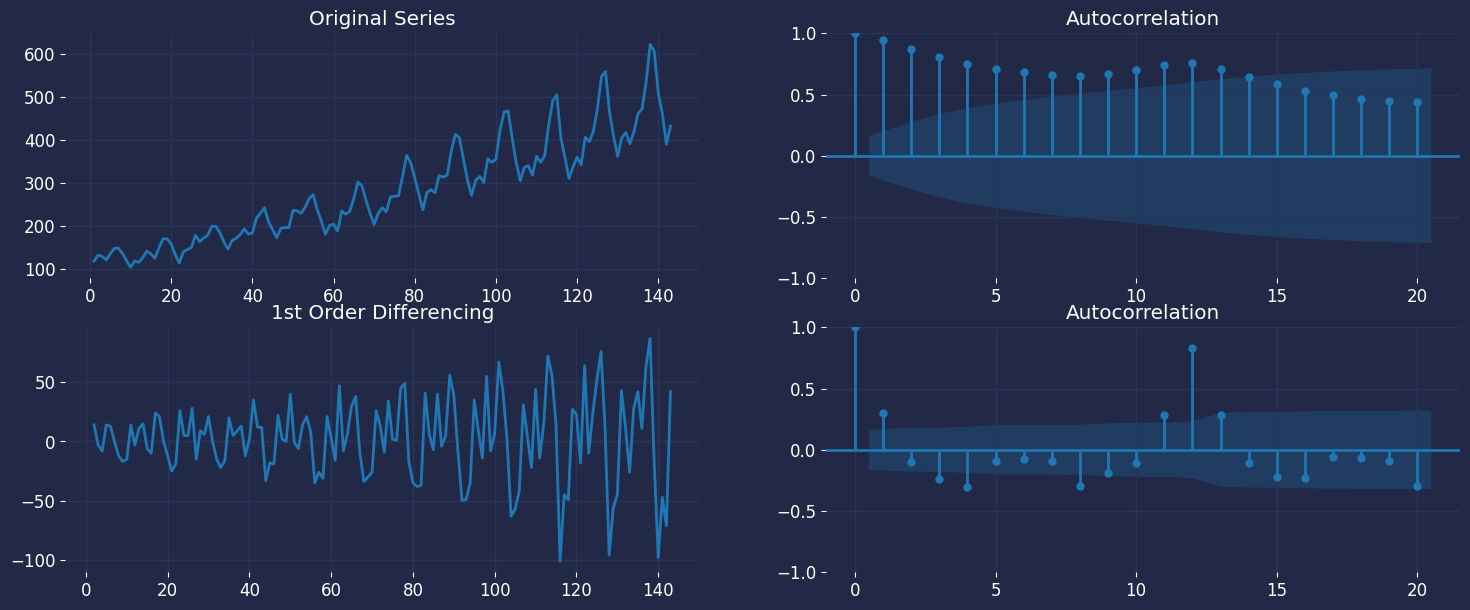

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, )
axes[0, 0].plot(df1["y"]); axes[0, 0].set_title('Original Series')
plot_acf(df1["y"], ax=axes[0, 1],lags=20)

axes[1, 0].plot(df1["y"].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df1["y"].diff().dropna(), ax=axes[1, 1],lags=20)


plt.show()

## Model Evaluation

In [36]:
df["ds"] = pd.to_datetime(df["ds"])

Y_train_df.shape, Y_test_df.shape

<ipython-input-36-b8aa2078b51d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ds"] = pd.to_datetime(df["ds"])


((264, 6), (24, 6))

##  AutoARIMA, AutoETS, AutoTheta with StatsForecast

In [37]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
from statsforecast.arima import arima_string

In [41]:
horizon = 12
season_length = horizon
horizon = len(Y_test_df)

models = [AutoARIMA(season_length=season_length),
          AutoETS(model='ZZZ', season_length=season_length),
          AutoTheta(season_length=season_length,
                     decomposition_type="additive",
                     model="STM")]

In [42]:
sf = StatsForecast(models=models, freq='M')
sf.fit(df=Y_train_df)

StatsForecast(models=[AutoARIMA,AutoETS,AutoTheta])

#### Residual analysis

In [43]:
arima_string(sf.fitted_[0,0].model_)

'Regression with ARIMA(2,0,0)(0,0,1)[12] errors'

In [44]:
#series index, model index
result=sf.fitted_[0,0].model_
print(result.keys())
print(result['arma'])

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])
(2, 0, 0, 1, 12, 0, 0)


In [45]:
#series index, model index
result=sf.fitted_[0,2].model_
print(result.keys())

dict_keys(['mse', 'amse', 'fit', 'residuals', 'm', 'states', 'par', 'n', 'modeltype', 'mean_y', 'decompose', 'decomposition_type', 'seas_forecast', 'fitted'])


In [46]:
residual=pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

,residual Model
0,88.837463
1,-17.467670
2,-19.915097
3,-2.363821
4,-17.249183
...,...
127,68.678997
128,-40.461005
129,-42.216655
130,-65.838836


<ipython-input-47-5137de7113d4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, ax=axs[0,1]);


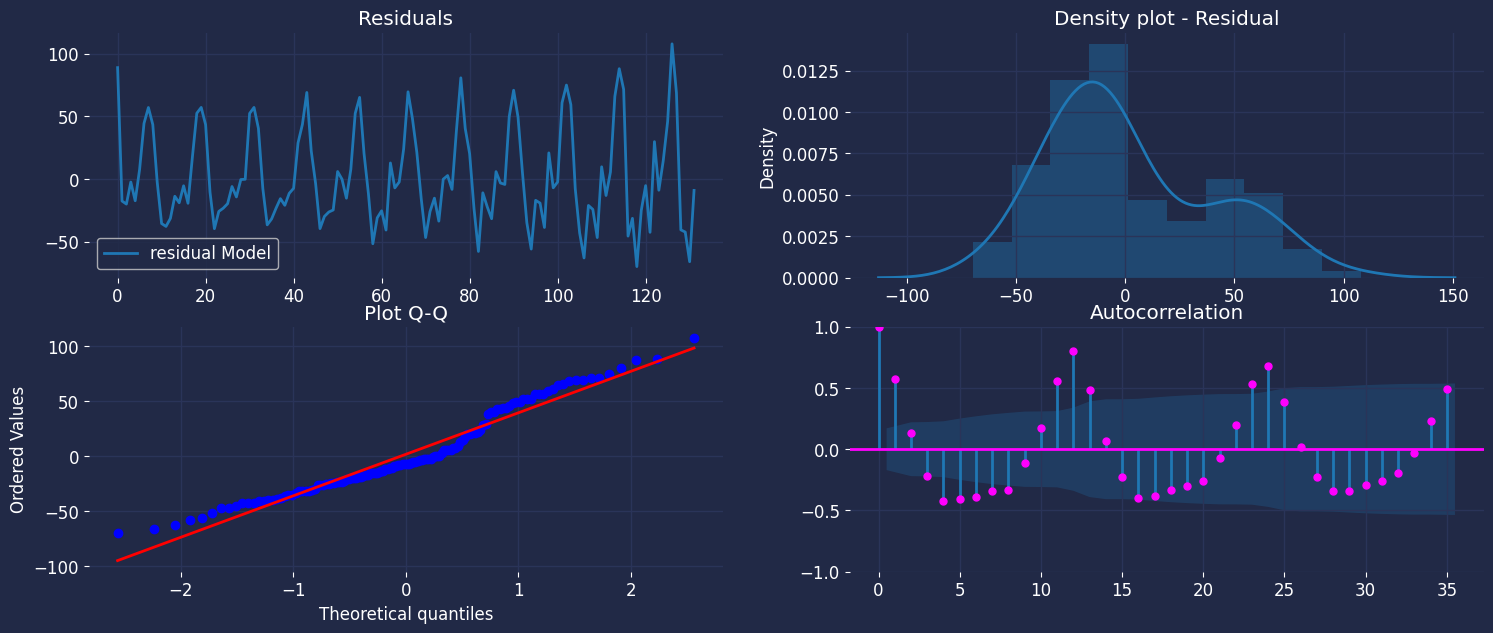

In [47]:
from scipy import stats


fig, axs = plt.subplots(nrows=2, ncols=2)

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals");

# plot
sns.distplot(residual, ax=axs[0,1]);
axs[0,1].set_title("Density plot - Residual");

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation");

plt.show();

### Forecasting results

In [48]:
Y_train_df = Y_train_df[['unique_id', 'ds', 'y']]
Y_test_df = Y_test_df[['unique_id', 'ds', 'y']]

In [49]:
Y_hat_df = sf.forecast(df=Y_train_df, h=horizon, fitted=True)

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


In [50]:
Y_hat_df

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,Airline1,1960-01-31,424.083771,406.651276,409.732178
1,Airline1,1960-02-29,407.042328,401.732910,401.535187
2,Airline1,1960-03-31,470.807709,456.289642,437.742371
3,Airline1,1960-04-30,460.865143,440.870514,428.862030
4,Airline1,1960-05-31,484.851074,440.333923,433.269196
5,Airline1,1960-06-30,536.854553,496.866058,472.380524
6,Airline1,1960-07-31,612.853699,545.839111,499.200195
7,Airline1,1960-08-31,623.853882,544.672485,498.715698
8,Airline1,1960-09-30,527.853821,477.034485,458.922882
9,Airline1,1960-10-31,471.853851,412.423096,425.250885


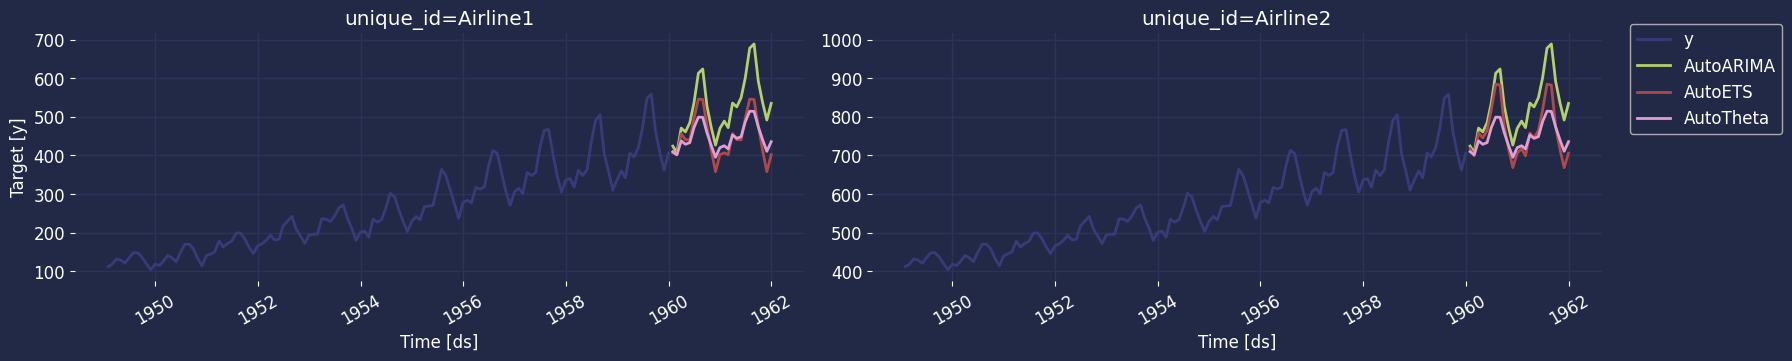

In [51]:
sf.plot(Y_train_df, Y_hat_df)

In [52]:
# values=sf.forecast_fitted_values()
# values

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


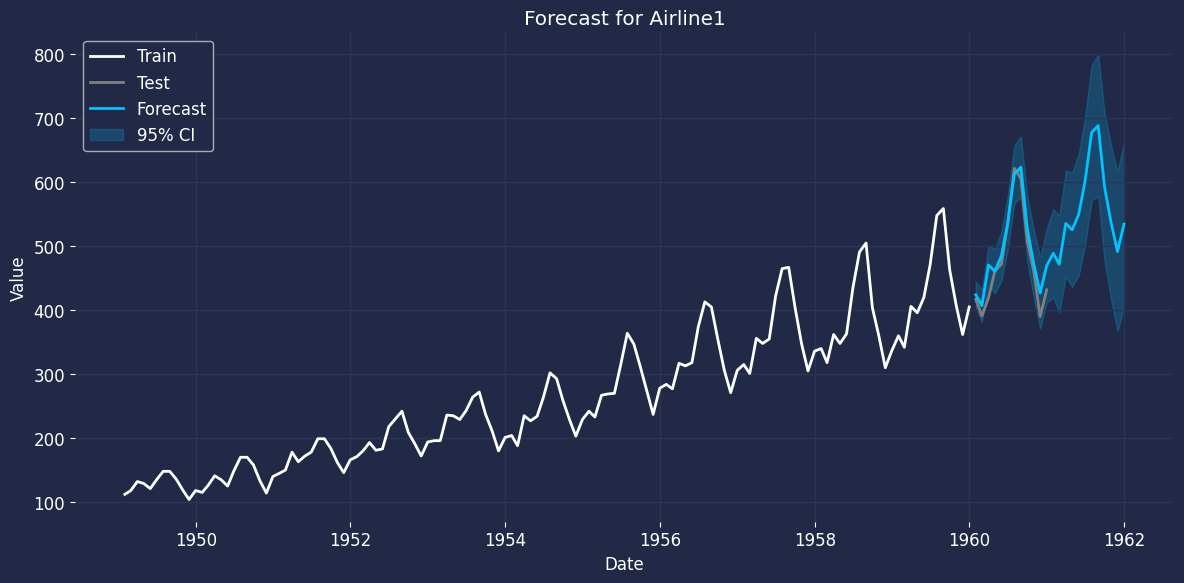

In [53]:
forecasts = sf.forecast(df=Y_train_df, h=horizon, level=[95])

uid = 'Airline1'
fcst = forecasts[forecasts['unique_id'] == uid]

# 실제값
y_train = Y_train_df[Y_train_df['unique_id'] == uid]
y_test = Y_test_df[Y_test_df['unique_id'] == uid]

plt.figure(figsize=(12, 6))

plt.plot(y_train['ds'], y_train['y'], label='Train', color='white')
plt.plot(y_test['ds'], y_test['y'], label='Test', color='gray')

# 예측값 (예: AutoARIMA)
plt.plot(fcst['ds'], fcst['AutoARIMA'], label='Forecast', color='#00C4FF')

plt.fill_between(fcst['ds'],
                 fcst['AutoARIMA-lo-95'],
                 fcst['AutoARIMA-hi-95'],
                 color='#00C4FF', alpha=0.2, label='95% CI')

plt.title(f'Forecast for {uid}', color='white')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
plot_df_sf = Y_test_df.merge(Y_hat_df, how='left', on=['unique_id', 'ds'])
plot_df_sf

,unique_id,ds,y,AutoARIMA,AutoETS,AutoTheta
0,Airline1,1960-01-31,417.0,424.083771,406.651276,409.732178
1,Airline1,1960-02-29,391.0,407.042328,401.732910,401.535187
2,Airline1,1960-03-31,419.0,470.807709,456.289642,437.742371
3,Airline1,1960-04-30,461.0,460.865143,440.870514,428.862030
4,Airline1,1960-05-31,472.0,484.851074,440.333923,433.269196
5,Airline1,1960-06-30,535.0,536.854553,496.866058,472.380524
6,Airline1,1960-07-31,622.0,612.853699,545.839111,499.200195
7,Airline1,1960-08-31,606.0,623.853882,544.672485,498.715698
8,Airline1,1960-09-30,508.0,527.853821,477.034485,458.922882
9,Airline1,1960-10-31,461.0,471.853851,412.423096,425.250885


In [55]:
model_names = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'NBEATS', 'NHITS', 'PatchTST', ]
cols = ['unique_id', 'ds', 'y'] +  model_names
fcst = pd.concat([plot_df_nf, plot_df_sf.drop(columns=['unique_id', 'ds', 'y'])], axis=1)[cols]

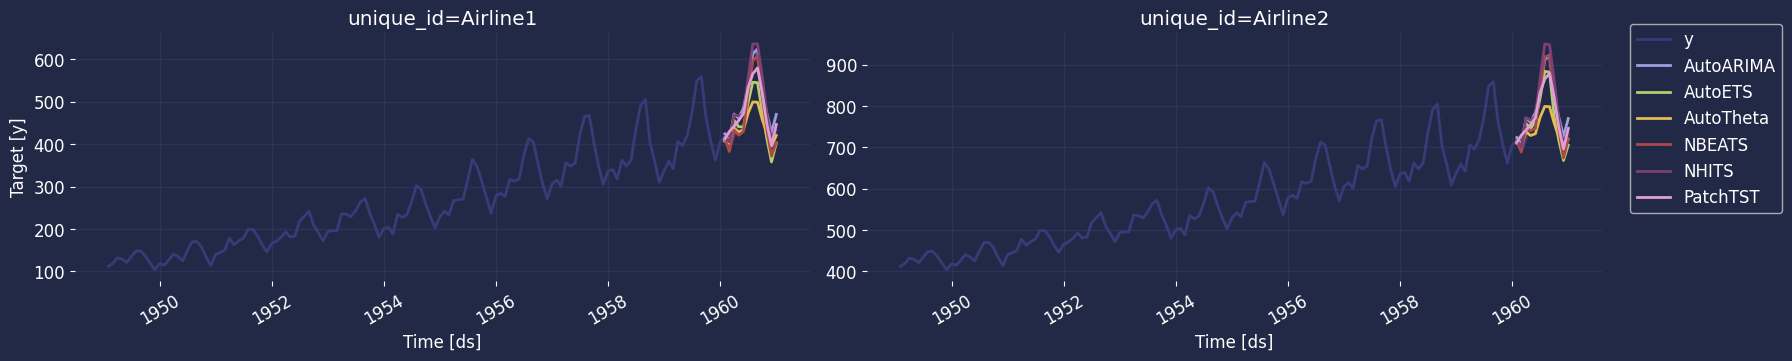

In [56]:
sf.plot(Y_train_df, fcst)
#sf.plot(Y_train_df, fcst, unique_ids=['Airline1'])

In [57]:
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [58]:
evals = evaluate(
    fcst,
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=season_length), ufl.rmse, ufl.smape],
    train_df=Y_train_df,
).sort_values(by='unique_id')

evals

,unique_id,metric,AutoARIMA,AutoETS,AutoTheta,NBEATS,NHITS,PatchTST
0,Airline1,mae,18.515821,35.612476,41.834316,18.977989,18.940924,17.072969
2,Airline1,mape,0.041797,0.072068,0.078947,0.040839,0.039866,0.035096
4,Airline1,mase,0.608073,1.169539,1.373869,0.623251,0.622034,0.560689
6,Airline1,rmse,23.919481,40.083622,55.836357,23.128807,25.152224,23.378281
8,Airline1,smape,0.020156,0.037253,0.041942,0.021010,0.019251,0.017498
1,Airline2,mae,18.515823,22.815207,41.834316,14.203380,21.770447,17.072973
3,Airline2,mape,0.024815,0.029162,0.050160,0.018533,0.027321,0.021521
5,Airline2,mase,0.608073,0.749268,1.373869,0.466449,0.714957,0.560689
7,Airline2,rmse,23.919481,26.413132,55.836357,16.934475,28.804110,23.378286
9,Airline2,smape,0.012149,0.014744,0.026114,0.009281,0.013343,0.010769


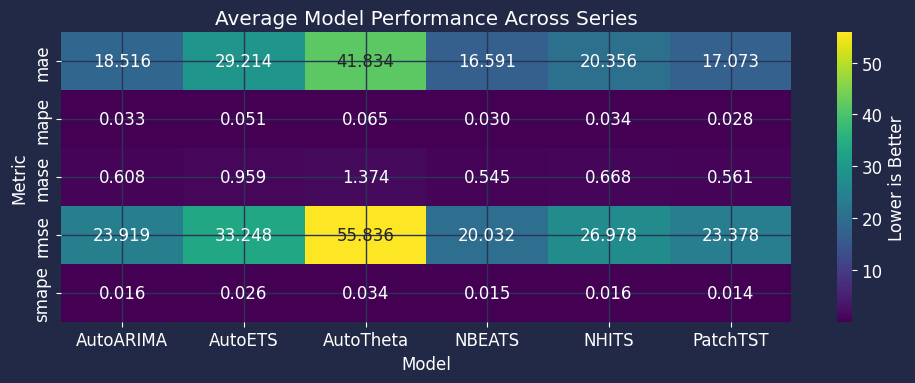

In [59]:
import seaborn as sns

df_avg = evals.groupby('metric')[model_names].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(df_avg, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Lower is Better'})
plt.title('Average Model Performance Across Series')
plt.ylabel('Metric')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

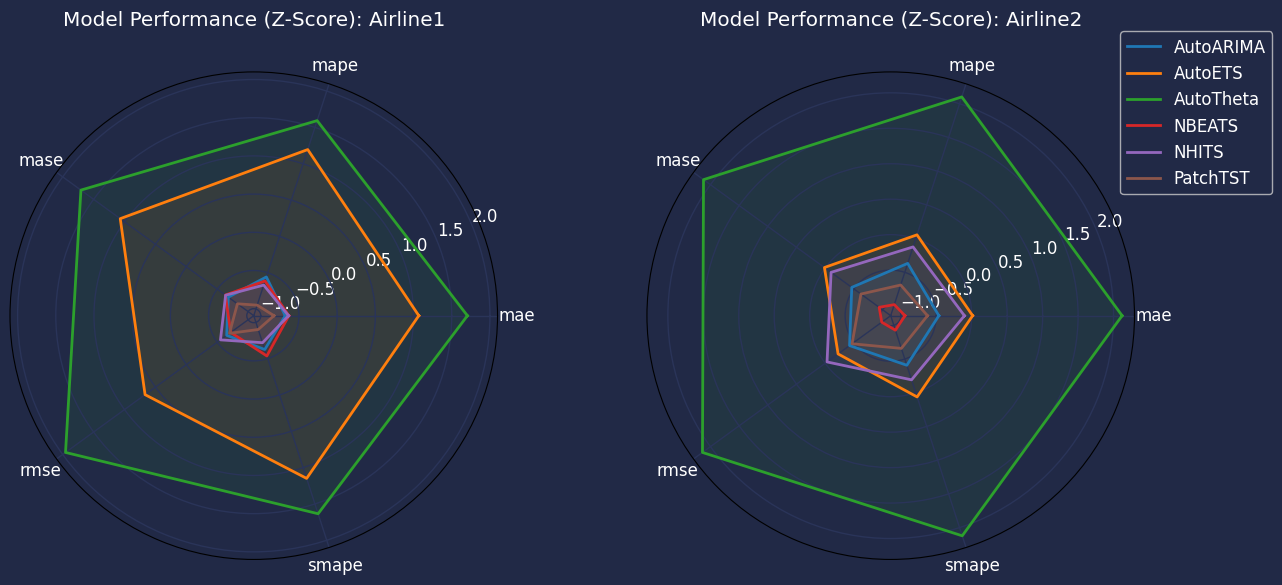

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 설정
unique_ids = evals['unique_id'].unique()
metrics = ['mae', 'mape', 'mase', 'rmse', 'smape']

n_series = len(unique_ids)
n_cols = 2
n_rows = int(np.ceil(len(unique_ids) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, uid in enumerate(unique_ids):
    ax = axes[idx]

    df_series = evals[evals['unique_id'] == uid].set_index('metric').loc[metrics, model_names]

    # row-wise Z-score 정규화
    df_scaled = pd.DataFrame(index=metrics, columns=model_names, dtype=float)
    for metric in metrics:
        row = df_series.loc[metric]
        if row.isna().all():
            continue
        scaled_row = StandardScaler().fit_transform(row.dropna().values.reshape(-1, 1)).flatten()
        df_scaled.loc[metric, row.dropna().index] = scaled_row

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    for model in model_names:
        if df_scaled[model].isna().any():
            continue
        values = df_scaled[model].tolist()
        values += values[:1]
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f'Model Performance (Z-Score): {uid}', y=1.08)
    ax.grid(True)

axes[-1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

for ax in axes[len(unique_ids):]:
    ax.axis('off')

plt.tight_layout()
plt.show()